In [3]:
import os
import glob
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch

from lameg.surf import create_surf_gifti
from lameg.viz import show_surface, color_map, rgbtoint
from lameg.util import get_bigbrain_layer_boundaries, load_meg_sensor_data, convert_native_to_fsaverage
from scipy.signal import correlate
import io
from PIL import Image
from base64 import b64decode
from scipy.io import savemat, loadmat

In [2]:
plt.rcParams.update({
    'font.size': 16,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

In [21]:
# Set FreeSurfer environment variables
os.environ['FREESURFER_HOME'] = '/usr/local/freesurfer'
os.environ['FSFAST_HOME'] = '/usr/local/freesurfer/fsfast'
os.environ['SUBJECTS_DIR'] = '/home/membercophy/Matteo_M/V1_ERF/BrainDyn_Data/Data/MRI'

# Add FreeSurfer binaries to PATH
os.environ['PATH'] = (
    f"{os.environ['FREESURFER_HOME']}/bin:"
    f"{os.environ['FREESURFER_HOME']}/fsfast/bin:"
    f"{os.environ['FREESURFER_HOME']}/tktools:"
    f"{os.environ['FREESURFER_HOME']}/mni/bin:"
    f"{os.environ['PATH']}"
)

# Print for verification
print(f"FREESURFER_HOME: {os.environ['FREESURFER_HOME']}")
print(f"FSFAST_HOME: {os.environ['FSFAST_HOME']}")
print(f"SUBJECTS_DIR: {os.environ['SUBJECTS_DIR']}")
print(f"PATH: {os.environ['PATH']}")

FREESURFER_HOME: /usr/local/freesurfer
FSFAST_HOME: /usr/local/freesurfer/fsfast
SUBJECTS_DIR: /home/membercophy/Matteo_M/V1_ERF/BrainDyn_Data/Data/MRI
PATH: /usr/local/freesurfer/bin:/usr/local/freesurfer/fsfast/bin:/usr/local/freesurfer/tktools:/usr/local/freesurfer/mni/bin:/usr/local/freesurfer/bin:/usr/local/freesurfer/fsfast/bin:/usr/local/freesurfer/tktools:/usr/local/freesurfer/mni/bin:/usr/local/freesurfer/bin:/usr/local/freesurfer/fsfast/bin:/usr/local/freesurfer/tktools:/usr/local/freesurfer/mni/bin:/usr/local/freesurfer/bin:/usr/local/freesurfer/fsfast/bin:/usr/local/freesurfer/tktools:/usr/local/freesurfer/mni/bin:/usr/local/freesurfer/bin:/usr/local/freesurfer/fsfast/bin:/usr/local/freesurfer/tktools:/usr/local/freesurfer/mni/bin:/usr/local/freesurfer/bin:/usr/local/freesurfer/fsfast/bin:/usr/local/freesurfer/tktools:/usr/local/freesurfer/mni/bin:/home/membercophy/miniconda3/envs/lameg_2025/bin:/home/membercophy/miniconda3/condabin:/usr/local/sbin:/usr/local/bin:/usr/sbin:

In [32]:
def align_to_abs_peak_with_edges_time(X, start_time=-0.3, peak_window=(0.05, 0.150), fs=600):
    """
    :param X: array (n_series, n_time)
    :param start_time: time of first sample (-0.3 или -0.5)
    :param peak_window; (t1, t2) in seconds — the window within which we search for |peak|
    :param fs: sampling frequency (default 600 Hz)

    Returns:
    lags:  shifts (n_series,)
    align_idx: indexes for alignment (list)
    peaks: peaks found for each participant
    ref_peak: average peak position
    """

    X = np.asarray(X)
    n_series, n_time = X.shape
    times = start_time + np.arange(n_time) / fs
    t1, t2 = peak_window
    i1 = np.searchsorted(times, t1)
    i2 = np.searchsorted(times, t2)
    i1 = max(0, i1)
    i2 = min(n_time, i2)
    peaks = np.array([
        i1 + np.argmax(np.abs(x[i1:i2]))
        for x in X
    ])
    ref_peak = int(round(np.mean(peaks)))
    lags = ref_peak - peaks

    base = np.arange(n_time)
    align_idx = [
        np.clip(base - lag, 0, n_time - 1)
        for lag in lags
    ]

    return lags, align_idx


In [ ]:
def upload_meg_file(rawdata_path, sub, ses, condition):
    """
    Search and upload the raw datachunck

    :param rawdata_path: datapath
    :param sub: subjects id
    :param ses: session id 
    :param condition: experimental condition (block-wise)
    """
    
    sub_meg_path = os.path.join(rawdata_path, "sub-" + sub , "ses-0" + ses , "meg/sub-"+ sub + "_ses-0" + ses + "_task-" + condition + "_acq-")
    folders_acq = glob.glob(sub_meg_path + "*_meg.ds", recursive=True)
    list_folders = sorted(folders_acq, key=lambda x: int(x.split('acq-')[1].split('_')[0]))
    
    return list_folders

subjects=['sub-105', 'sub-107', 'sub-109', 'sub-113', 'sub-114',
           'sub-115', 'sub-117','sub-118','sub-119', 'sub-123', 
           'sub-124', 'sub-126','sub-127','sub-129', 'sub-130',
           'sub-131','sub-132','sub-133','sub-134','sub-135', 
           'sub-136', 'sub-137','sub-138', 'sub-141','sub-142',
           'sub-143','sub-144','sub-145']

sessions = {
    'sub-105': ['ses-01'], 'sub-107': ['ses-01'], 'sub-109': ['ses-01'], 'sub-113': ['ses-01'], 
    'sub-114': ['ses-01'], 'sub-115': ['ses-01'],'sub-117': ['ses-01'], 'sub-118': ['ses-01'], 
    'sub-119': ['ses-01'], 'sub-123': ['ses-01'],'sub-124': ['ses-01'], 'sub-126': ['ses-01'], 
    'sub-127': ['ses-01'], 'sub-129': ['ses-01'],'sub-130': ['ses-01'], 'sub-131': ['ses-01'],
    'sub-132': ['ses-01'], 'sub-133': ['ses-01'],'sub-134': ['ses-01'], 'sub-135': ['ses-01'], 
    'sub-136': ['ses-01'], 'sub-137': ['ses-01'], 'sub-138': ['ses-01'],'sub-141': ['ses-01'], 
    'sub-142': ['ses-01'], 'sub-143': ['ses-01'], 'sub-144': ['ses-01'],
    'sub-145': ['ses-01']
}

n_layers=11

time_lims=[-300,300]
out_dir="/home/membercophy/Matteo_M/V1_ERF/results"
braindyn_files = "/home/membercophy/Matteo_M/V1_ERF/BrainDyn_Data/Data/MRI"
figures_path = ""
meg_rawdata_path = "/home/membercophy/Matteo_M/V1_ERF/rawdata"

# all_snrs=[]
fsave_lh_coords, fsave_lh_faces = nib.freesurfer.io.read_geometry('/home/membercophy/SUB_FS_DIR_DEFAULT/fsaverage/surf/lh.inflated')
fsave_rh_coords, fsave_rh_faces = nib.freesurfer.io.read_geometry('/home/membercophy/SUB_FS_DIR_DEFAULT/fsaverage/surf/rh.inflated')


SUB = ['105', '107', '109', '113', '114',
        '115', '117','118','119', '123', 
        '124', '126','127','129', '130',
        '131','132','133','134', '135', 
        '136', '137','138', '141','142',
        '143','144','145']

ses = "1"
condition = "V100V100"
mxf_option = "no_mxf" 
trigger = "right_stim" # just for SNR computation

snrs_subj = []

for s, sub in enumerate(SUB): 
    
    print(f"Computing sub {sub} SNR")

    list_folders = upload_meg_file(meg_rawdata_path, sub, ses, condition)
    mxf_path_dir = os.path.join(list_folders[-1], f"mxf_{mxf_option}_data")

    output_spm_conv_dir = os.path.join(mxf_path_dir, "mxf_sess_data", "spm_convert_epo")
    spm_converted_file = f"spm_sub-{sub}_ses-0{ses}_task-{condition}_meg_{mxf_option}_{trigger}_nrg_ERF_epo"
    base_fname = os.path.join(output_spm_conv_dir,spm_converted_file + ".mat")

    sensor_data, sensor_time, ch_names = load_meg_sensor_data(base_fname)
    st_idx=np.where((sensor_time>=time_lims[0]) & (sensor_time<=time_lims[1]))[0]
    sensor_data=sensor_data[:,st_idx,:]
    sensor_time=sensor_time[st_idx]
    # Compute mean signal across trials (shape: n_channels x n_times)
    mean_signal = np.mean(sensor_data, axis=2)
    # Compute residual noise (trial-by-trial deviations from mean)
    noise = sensor_data - mean_signal[:, :, np.newaxis]
    # Compute RMS of signal and noise over channels
    rms_signal = np.sqrt(np.mean(mean_signal**2, axis=0))  # shape: (n_times,)
    rms_noise = np.sqrt(np.mean(np.mean(noise**2, axis=2), axis=0))  # shape: (n_times,)
    # Compute SNR time series in dB
    snr_db = 20 * np.log10(rms_signal / rms_noise)
    snrs_subj.append(snr_db)

snrs_all = np.array(snrs_subj)
mean_snr_sub = np.mean(snrs_all, axis=1)
thresh_snr = -15
threshold = mean_snr_sub < thresh_snr
exclude_indices = np.where(threshold)[0]
hi_snr_subjects = [item for i, item in enumerate(subjects) if i not in exclude_indices]
lo_snr_subjects = [item for i, item in enumerate(subjects) if i in exclude_indices]
print(f"HI SNR subjects: {hi_snr_subjects}")
print(f"LO SNR subjects: {lo_snr_subjects}")
num_subj = len(hi_snr_subjects)

# RIGHT Attention loop

all_lh_ra_prior_ts=[]
all_lh_ra_F_diff=[]
all_lh_ra_layer_F_diff=[]
all_lh_ra_bb_boundaries=[]
all_lh_ra_layer_F = []

all_rh_ra_prior_ts=[]
all_rh_ra_F_diff=[]
all_rh_ra_layer_F_diff=[]
all_rh_ra_bb_boundaries=[]
all_rh_ra_layer_F = []

subj_ra_idx = {}
overall_ra_idx = 0 

for subject in hi_snr_subjects:
    sub_n=subject.split('-')[-1]
    for sess_idx, session in enumerate(sessions[subject]):
        subj_ra_idx[subject] = []

        out_fname = os.path.join(out_dir,f'results_{subject}_{session}_right_stim.npz') 
        if os.path.exists(out_fname):

            output_spm_conv_dir = os.path.join(mxf_path_dir, "mxf_sess_data", "spm_convert_epo")
            spm_converted_file = f"spm_sub-{sub}_ses-0{ses}_task-{condition}_meg_{mxf_option}_{trigger}_nrg_ERF_epo"
            base_fname = os.path.join(output_spm_conv_dir,spm_converted_file + ".mat")

            sensor_data, sensor_time, ch_names = load_meg_sensor_data(os.path.join(output_spm_conv_dir, base_fname))
            sensor_time=sensor_time
            
            st_idx=np.where((sensor_time>=time_lims[0]) & (sensor_time<=time_lims[1]))[0]
            sensor_data=sensor_data[:,st_idx,:]
            sensor_time=sensor_time[st_idx]
            
            subj_surf_dir=os.path.join(braindyn_files,f'{sub_n}-synth','layer_surf')
            ds_pial = nib.load(os.path.join(subj_surf_dir, 'pial.ds.gii'))

            data = np.load(out_fname, allow_pickle=True)

            lh_prior = data['lh_prior']
            lh_prior_ts = data['lh_prior_ts']*1000
            ts_time = data['ts_time']
            lh_Fs = data['lh_Fs']
            wois = data['wois']
            
            rh_prior = data['rh_prior']
            rh_prior_ts = data['rh_prior_ts']*1000
            rh_Fs = data['rh_Fs']

            lh_ra_prior_coord=ds_pial.darrays[0].data[lh_prior,:]
            lh_ra_hemi, lh_ra_fsave_idx = convert_native_to_fsaverage(sub_n +"-synth", subj_surf_dir, subj_coord=lh_ra_prior_coord)
            lh_fsave_coord = fsave_lh_coords[lh_ra_fsave_idx]
            
            rh_ra_prior_coord=ds_pial.darrays[0].data[rh_prior,:]
            rh_ra_hemi, rh_ra_fsave_idx = convert_native_to_fsaverage(sub_n +"-synth", subj_surf_dir, subj_coord=rh_ra_prior_coord)
            rh_fsave_coord = fsave_rh_coords[rh_ra_fsave_idx]

            woi_time=np.mean(wois,axis=-1)
            t_idx=np.where((woi_time>=time_lims[0]) & (woi_time<=time_lims[1]))[0]
            woi_win=woi_time[t_idx]
            lh_Fs_win=lh_Fs[:,t_idx]
            rh_Fs_win=rh_Fs[:,t_idx]

            ts_idx=np.where((ts_time>=time_lims[0]) & (ts_time<=time_lims[1]))[0]
            lh_prior_ts=lh_prior_ts[ts_idx]
            rh_prior_ts=rh_prior_ts[ts_idx]
            ts_time=ts_time[ts_idx]
            
            lh_surf_bb_bounds=n_layers*get_bigbrain_layer_boundaries(f'{sub_n}-synth', subj_surf_dir, subj_coord=ds_pial.darrays[0].data[lh_prior,:])
            rh_surf_bb_bounds=n_layers*get_bigbrain_layer_boundaries(f'{sub_n}-synth', subj_surf_dir, subj_coord=ds_pial.darrays[0].data[rh_prior,:])

            #prior_ts = session_polarity*prior_ts

            layers=np.arange(n_layers)
            lh_infra_gran_idx=np.where((layers<lh_surf_bb_bounds[2]))[0]
            lh_gran_idx=np.where((layers>=lh_surf_bb_bounds[2]) & (layers<lh_surf_bb_bounds[3]))[0]
            lh_supgra_gran_idx=np.where((layers>=lh_surf_bb_bounds[3]))[0]

            rh_infra_gran_idx=np.where((layers<rh_surf_bb_bounds[2]))[0]
            rh_gran_idx=np.where((layers>=rh_surf_bb_bounds[2]) & (layers<rh_surf_bb_bounds[3]))[0]
            rh_supgra_gran_idx=np.where((layers>=rh_surf_bb_bounds[3]))[0]

            lh_layer_F = np.vstack([
                np.mean(lh_Fs_win[lh_infra_gran_idx,:],axis=0),
                np.mean(lh_Fs_win[lh_gran_idx,:],axis=0),
                np.mean(lh_Fs_win[lh_supgra_gran_idx,:],axis=0)
            ])
            lh_layer_F_diff = np.zeros((lh_layer_F.shape[0],lh_layer_F.shape[1]))
            for t in range(lh_layer_F.shape[1]):
                minF = np.nanmin(lh_layer_F[:,t])
                lh_layer_F_diff[:,t] = lh_layer_F[:,t]-minF
            
            rh_layer_F = np.vstack([
                np.mean(rh_Fs_win[rh_infra_gran_idx,:],axis=0),
                np.mean(rh_Fs_win[rh_gran_idx,:],axis=0),
                np.mean(rh_Fs_win[rh_supgra_gran_idx,:],axis=0)
            ])
            rh_layer_F_diff = np.zeros((rh_layer_F.shape[0],rh_layer_F.shape[1]))
            for t in range(rh_layer_F.shape[1]):
                minF = np.nanmin(rh_layer_F[:,t])
                rh_layer_F_diff[:,t] = rh_layer_F[:,t]-minF

            subj_ra_idx[subject].append(overall_ra_idx)
            all_lh_ra_prior_ts.append(lh_prior_ts)
            all_rh_ra_prior_ts.append(rh_prior_ts)
            all_lh_ra_layer_F.append(lh_layer_F)
            all_rh_ra_layer_F.append(rh_layer_F)
            all_lh_ra_layer_F_diff.append(lh_layer_F_diff)
            all_rh_ra_layer_F_diff.append(rh_layer_F_diff)
            overall_ra_idx = overall_ra_idx+1



Computing sub 105 SNR
Computing sub 107 SNR
Computing sub 109 SNR
Computing sub 113 SNR
Computing sub 114 SNR
Computing sub 115 SNR
Computing sub 117 SNR
Computing sub 118 SNR
Computing sub 119 SNR
Computing sub 123 SNR
Computing sub 124 SNR
Computing sub 126 SNR
Computing sub 127 SNR
Computing sub 129 SNR
Computing sub 130 SNR
Computing sub 131 SNR
Computing sub 132 SNR
Computing sub 133 SNR
Computing sub 134 SNR
Computing sub 135 SNR
Computing sub 136 SNR
Computing sub 137 SNR
Computing sub 138 SNR
Computing sub 141 SNR
Computing sub 142 SNR
Computing sub 143 SNR
Computing sub 144 SNR
Computing sub 145 SNR
HI SNR subjects: ['sub-107', 'sub-109', 'sub-113', 'sub-115', 'sub-117', 'sub-118', 'sub-119', 'sub-123', 'sub-126', 'sub-127', 'sub-129', 'sub-130', 'sub-131', 'sub-134', 'sub-135', 'sub-136', 'sub-138', 'sub-143', 'sub-144', 'sub-145']
LO SNR subjects: ['sub-105', 'sub-114', 'sub-124', 'sub-132', 'sub-133', 'sub-137', 'sub-141', 'sub-142']


/home/membercophy/miniconda3/envs/lameg_2025/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/home/membercophy/miniconda3/envs/lameg_2025/lib/python3.7/site-packages/numpy/core/_methods.py:182: RuntimeWarning: invalid value encountered in true_divide
  ret, rcount, out=ret, casting='unsafe', subok=False)


In [85]:
all_lh_ra_prior_ts=np.array(all_lh_ra_prior_ts)
all_rh_ra_prior_ts=np.array(all_rh_ra_prior_ts)

all_lh_ra_layer_F=np.array(all_lh_ra_layer_F)
all_rh_ra_layer_F=np.array(all_rh_ra_layer_F)

all_rh_ra_layer_F_diff=np.array(all_lh_ra_layer_F_diff)
all_rh_ra_layer_F_diff=np.array(all_rh_ra_layer_F_diff)

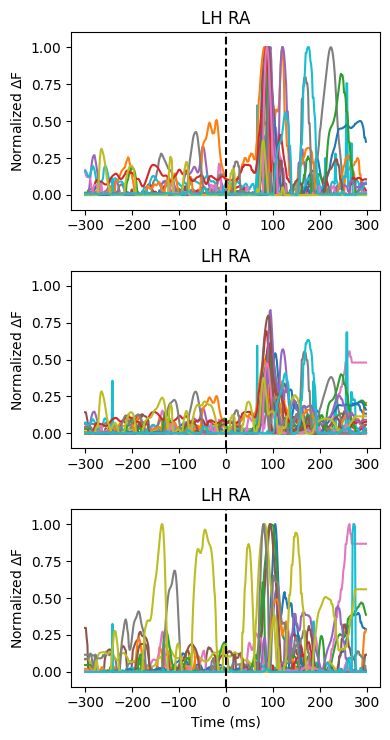

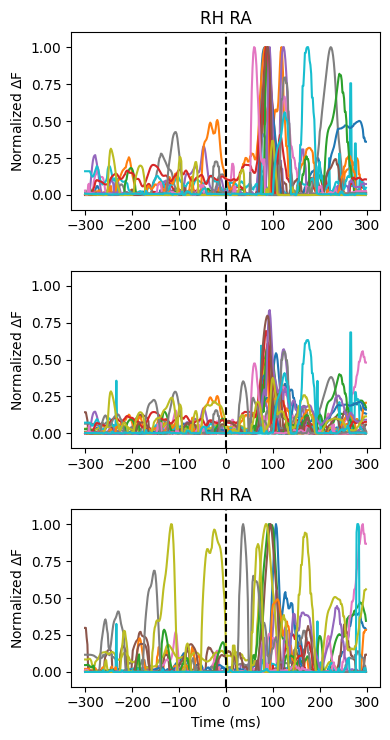

In [ ]:
def align_norm_plot_data(all_prior_ts, all_layer_F, all_layer_F_diff, subjects, subj_attention_idx, hemi_label):

    F = np.array(all_layer_F).copy()
    F_diff = np.array(all_layer_F_diff).copy()
    all_prior_ts = np.array(all_prior_ts)
    
    for s_idx in range(F.shape[0]):
        for l_idx in range(F.shape[1]):
            # Fill NaNs by averaging neighbors
            if np.any(np.isnan(F[s_idx, l_idx, :])):
                prev_row = F[s_idx, max(0, l_idx - 1), :]
                next_row = F[s_idx, min(F.shape[1]-1, l_idx + 1), :]
                F[s_idx, l_idx, :] = 0.5 * (prev_row + next_row)
                
            if np.any(np.isnan(F_diff[s_idx, l_idx, :])):
                prev_row = F_diff[s_idx, max(0, l_idx - 1), :]
                next_row = F_diff[s_idx, min(F_diff.shape[1]-1, l_idx + 1), :]
                F_diff[s_idx, l_idx, :] = 0.5 * (prev_row + next_row)

    lags, align_idx = align_to_abs_peak_with_edges_time(all_prior_ts, peak_window=(0.05, 0.150))
    
    aligned_prior_ts = []
    aligned_layer_F = []
    aligned_layer_F_diff = []

    for ss_idx in range(all_prior_ts.shape[0]):
        idx = align_idx[ss_idx]
        aligned_prior_ts.append(all_prior_ts[ss_idx, idx])
        aligned_layer_F.append(F[ss_idx, :, idx])
        aligned_layer_F_diff.append(F_diff[ss_idx, :, idx])

    aligned_prior_ts = np.array(aligned_prior_ts)
    # Transpose to maintain (subjects, layers, time)
    aligned_layer_F = np.transpose(np.array(aligned_layer_F), (0, 2, 1))
    aligned_layer_F_diff = np.transpose(np.array(aligned_layer_F_diff), (0, 2, 1))

    # 3. Subject-level averaging (Aligned)
    aligned_subjects_m_layer_F_diff = []
    for s_idx, subject in enumerate(subjects):
        sess_idx = subj_attention_idx[subject]
        subj_m_layer_F_diff = np.nanmean(aligned_layer_F_diff[sess_idx, :, :], axis=0)
        aligned_subjects_m_layer_F_diff.append(subj_m_layer_F_diff)

    aligned_subjects_m_layer_F_diff = np.array(aligned_subjects_m_layer_F_diff)

    # 4. Normalization and Plotting
    norm_m_layer_F_diff = np.zeros(aligned_subjects_m_layer_F_diff.shape)
    plt.figure(figsize=(4, 2.5 * 3))
    
    for s_idx in range(aligned_subjects_m_layer_F_diff.shape[0]):
        subj_data = aligned_subjects_m_layer_F_diff[s_idx, :, :]
        # Normalize by max of the entire subject's layer-time matrix
        norm_subj = subj_data / np.nanmax(subj_data)
        norm_m_layer_F_diff[s_idx, :, :] = norm_subj

    n_plots = norm_m_layer_F_diff.shape[1]
    for l_idx in range(n_plots):
        plt.subplot(n_plots, 1, l_idx + 1)
        plt.plot(woi_win, norm_m_layer_F_diff[:, l_idx, :].T)
        plt.ylim([-0.1, 1.1])
        plt.axvline(0, color='k', linestyle='--')
        plt.title(f"{hemi_label}")
        plt.ylabel(r"Normalized $\Delta$F")
    
    plt.xlabel('Time (ms)')
    plt.tight_layout()
    #plt.savefig(f'./figure_{hemi_label}_aligned_subjects.pdf')
    
    return norm_m_layer_F_diff

# Right attention Left Hemisphere
lh_ra_norm_diff = align_norm_plot_data(
    all_lh_ra_prior_ts, 
    all_lh_ra_layer_F, 
    all_lh_ra_layer_F_diff, 
    hi_snr_subjects, 
    subj_ra_idx, 
    "LH RA"
)

# Right attention Right Hemisphere
rh_ra_norm_diff = align_norm_plot_data(
    all_rh_ra_prior_ts, 
    all_rh_ra_layer_F, 
    all_rh_ra_layer_F_diff, 
    hi_snr_subjects, 
    subj_ra_idx, 
    "RH RA"
)

In [89]:
# left attention

all_lh_la_prior_ts=[]
all_lh_la_F_diff=[]
all_lh_la_layer_F_diff=[]
all_lh_la_bb_boundaries=[]
all_lh_la_layer_F = []

all_rh_la_prior_ts=[]
all_rh_la_F_diff=[]
all_rh_la_layer_F_diff=[]
all_rh_la_bb_boundaries=[]
all_rh_la_layer_F = []

subj_la_idx = {}

overall_la_idx = 0 

for subject in hi_snr_subjects:
    sub_n=subject.split('-')[-1]
    for sess_idx, session in enumerate(sessions[subject]):
        subj_la_idx[subject] = []

        out_fname = os.path.join(out_dir,f'results_{subject}_{session}_left_stim.npz') 
        if os.path.exists(out_fname):

            output_spm_conv_dir = os.path.join(mxf_path_dir, "mxf_sess_data", "spm_convert_epo")
            spm_converted_file = f"spm_sub-{sub}_ses-0{ses}_task-{condition}_meg_{mxf_option}_{trigger}_nrg_ERF_epo"
            base_fname = os.path.join(output_spm_conv_dir,spm_converted_file + ".mat")

            sensor_data, sensor_time, ch_names = load_meg_sensor_data(os.path.join(output_spm_conv_dir, base_fname))
            sensor_time=sensor_time
            
            st_idx=np.where((sensor_time>=time_lims[0]) & (sensor_time<=time_lims[1]))[0]
            sensor_data=sensor_data[:,st_idx,:]
            sensor_time=sensor_time[st_idx]
            
            subj_surf_dir=os.path.join(braindyn_files,f'{sub_n}-synth','layer_surf')
            ds_pial = nib.load(os.path.join(subj_surf_dir, 'pial.ds.gii'))

            data = np.load(out_fname, allow_pickle=True)

            lh_prior = data['lh_prior']
            lh_prior_ts = data['lh_prior_ts']*1000
            ts_time = data['ts_time']
            lh_Fs = data['lh_Fs']
            wois = data['wois']
            
            rh_prior = data['rh_prior']
            rh_prior_ts = data['rh_prior_ts']*1000
            rh_Fs = data['rh_Fs']

            lh_la_prior_coord=ds_pial.darrays[0].data[lh_prior,:]
            lh_la_hemi, lh_la_fsave_idx = convert_native_to_fsaverage(sub_n +"-synth", subj_surf_dir, subj_coord=lh_la_prior_coord)
            lh_fsave_coord = fsave_lh_coords[lh_la_fsave_idx]
            
            rh_la_prior_coord=ds_pial.darrays[0].data[rh_prior,:]
            rh_la_hemi, rh_la_fsave_idx = convert_native_to_fsaverage(sub_n +"-synth", subj_surf_dir, subj_coord=rh_la_prior_coord)
            rh_fsave_coord = fsave_rh_coords[rh_la_fsave_idx]

            woi_time=np.mean(wois,axis=-1)
            t_idx=np.where((woi_time>=time_lims[0]) & (woi_time<=time_lims[1]))[0]
            woi_win=woi_time[t_idx]
            lh_Fs_win=lh_Fs[:,t_idx]
            rh_Fs_win=rh_Fs[:,t_idx]

            ts_idx=np.where((ts_time>=time_lims[0]) & (ts_time<=time_lims[1]))[0]
            lh_prior_ts=lh_prior_ts[ts_idx]
            rh_prior_ts=rh_prior_ts[ts_idx]
            ts_time=ts_time[ts_idx]
            
            lh_surf_bb_bounds=n_layers*get_bigbrain_layer_boundaries(f'{sub_n}-synth', subj_surf_dir, subj_coord=ds_pial.darrays[0].data[lh_prior,:])
            rh_surf_bb_bounds=n_layers*get_bigbrain_layer_boundaries(f'{sub_n}-synth', subj_surf_dir, subj_coord=ds_pial.darrays[0].data[rh_prior,:])

            #prior_ts = session_polarity*prior_ts

            layers=np.arange(n_layers)
            lh_infra_gran_idx=np.where((layers<lh_surf_bb_bounds[2]))[0]
            lh_gran_idx=np.where((layers>=lh_surf_bb_bounds[2]) & (layers<lh_surf_bb_bounds[3]))[0]
            lh_supgra_gran_idx=np.where((layers>=lh_surf_bb_bounds[3]))[0]

            rh_infra_gran_idx=np.where((layers<rh_surf_bb_bounds[2]))[0]
            rh_gran_idx=np.where((layers>=rh_surf_bb_bounds[2]) & (layers<rh_surf_bb_bounds[3]))[0]
            rh_supgra_gran_idx=np.where((layers>=rh_surf_bb_bounds[3]))[0]

            lh_layer_F = np.vstack([
                np.mean(lh_Fs_win[lh_infra_gran_idx,:],axis=0),
                np.mean(lh_Fs_win[lh_gran_idx,:],axis=0),
                np.mean(lh_Fs_win[lh_supgra_gran_idx,:],axis=0)
            ])
            lh_layer_F_diff = np.zeros((lh_layer_F.shape[0],lh_layer_F.shape[1]))
            for t in range(lh_layer_F.shape[1]):
                minF = np.nanmin(lh_layer_F[:,t])
                lh_layer_F_diff[:,t] = lh_layer_F[:,t]-minF
            
            rh_layer_F = np.vstack([
                np.mean(rh_Fs_win[rh_infra_gran_idx,:],axis=0),
                np.mean(rh_Fs_win[rh_gran_idx,:],axis=0),
                np.mean(rh_Fs_win[rh_supgra_gran_idx,:],axis=0)
            ])
            rh_layer_F_diff = np.zeros((rh_layer_F.shape[0],rh_layer_F.shape[1]))
            for t in range(rh_layer_F.shape[1]):
                minF = np.nanmin(rh_layer_F[:,t])
                rh_layer_F_diff[:,t] = rh_layer_F[:,t]-minF

            subj_la_idx[subject].append(overall_la_idx)
            all_lh_la_prior_ts.append(lh_prior_ts)
            all_rh_la_prior_ts.append(rh_prior_ts)
            all_lh_la_layer_F.append(lh_layer_F)
            all_rh_la_layer_F.append(rh_layer_F)
            all_lh_la_layer_F_diff.append(lh_layer_F_diff)
            all_rh_la_layer_F_diff.append(rh_layer_F_diff)
            overall_la_idx = overall_la_idx+1

/home/membercophy/miniconda3/envs/lameg_2025/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/home/membercophy/miniconda3/envs/lameg_2025/lib/python3.7/site-packages/numpy/core/_methods.py:182: RuntimeWarning: invalid value encountered in true_divide
  ret, rcount, out=ret, casting='unsafe', subok=False)


In [80]:
all_lh_la_prior_ts=np.array(all_lh_la_prior_ts)
all_rh_la_prior_ts=np.array(all_rh_la_prior_ts)

all_lh_la_layer_F=np.array(all_lh_la_layer_F)
all_rh_la_layer_F=np.array(all_rh_la_layer_F)

all_rh_la_layer_F_diff=np.array(all_lh_la_layer_F_diff)
all_rh_la_layer_F_diff=np.array(all_rh_la_layer_F_diff)

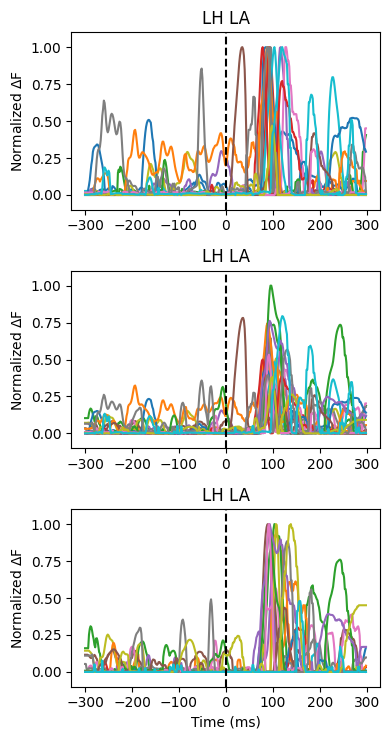

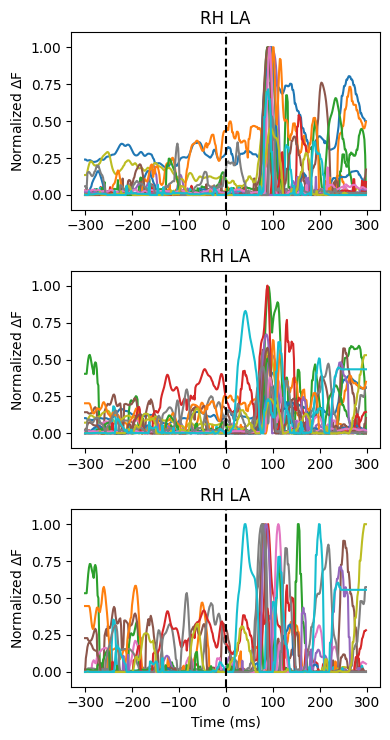

In [ ]:
# Left attention Left Hemisphere
lh_ra_norm_diff = align_norm_plot_data(
    all_lh_la_prior_ts, 
    all_lh_la_layer_F, 
    all_lh_la_layer_F_diff, 
    hi_snr_subjects, 
    subj_la_idx, 
    "LH LA"
)

# Left attention Right Hemisphere
rh_ra_norm_diff = align_norm_plot_data(
    all_rh_la_prior_ts, 
    all_rh_la_layer_F, 
    all_rh_la_layer_F_diff, 
    hi_snr_subjects, 
    subj_la_idx, 
    "RH LA"
)

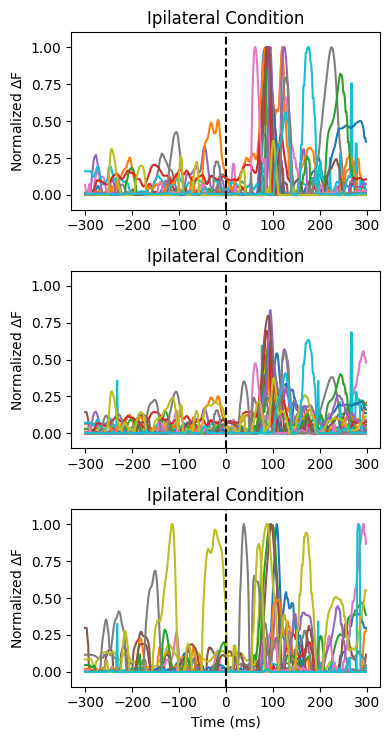

In [91]:
ipsilateral_prior_ts = np.concatenate((all_rh_ra_prior_ts, all_lh_la_prior_ts))
ipsilateral_layer_F=np.concatenate((all_rh_ra_layer_F, all_lh_la_layer_F))
ipsilateral_layer_F_diff =np.concatenate((all_rh_ra_layer_F_diff, all_lh_la_layer_F_diff))

ipsilateral_norm_diff = align_norm_plot_data(
    ipsilateral_prior_ts, 
    ipsilateral_layer_F, 
    ipsilateral_layer_F_diff, 
    hi_snr_subjects, 
    subj_la_idx, 
    "Ipilateral Condition"
)

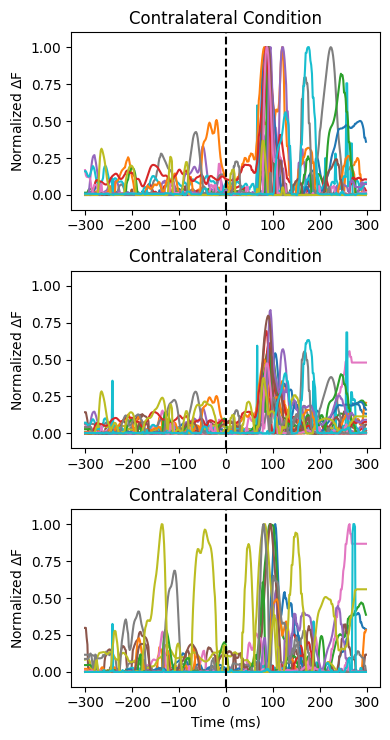

In [92]:
contralateral_prior_ts = np.concatenate((all_lh_ra_prior_ts, all_rh_la_prior_ts))
contralateral_layer_F=np.concatenate((all_lh_ra_layer_F, all_rh_la_layer_F))
contralateral_layer_F_diff =np.concatenate((all_lh_ra_layer_F_diff, all_rh_la_layer_F_diff))

contralateral_norm_diff = align_norm_plot_data(
    contralateral_prior_ts, 
    contralateral_layer_F, 
    contralateral_layer_F_diff, 
    hi_snr_subjects, 
    subj_la_idx, 
    "Contralateral Condition"
)